In [5]:
# ============================================================
# Figure 1 — Empirical distribution of fitted initial conditions
# Output: pix/ic_distribution.pdf
# ============================================================
# Empirical distribution of fitted initial conditions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})
bads = ["AK", "HI", "AZ"]
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')], ignore_index=True).query("state1 not in @bads and state2 not in @bads")

S_vals = pd.concat([res['S1_0'], res['S2_0']])
I_vals = pd.concat([res['I1_0'], res['I2_0']])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(S_vals, kde=True, ax=ax1, bins=30, color='steelblue', edgecolor='white')
ax1.set_xlabel(r'$S_i(0) / N_i$', fontsize=18)
ax1.set_ylabel('Count', fontsize=18)
ax1.grid(True, alpha=0.3)

sns.histplot(np.log10(I_vals[I_vals > 0]), kde=True, ax=ax2, bins=30, color='darkorange', edgecolor='white')
ax2.set_xlabel(r'$\log_{10}(I_i(0) / N_i)$', fontsize=18)
ax2.set_ylabel('Count', fontsize=18)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pix/ic_distribution.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/ic_distribution.pdf', bbox_inches='tight')
#plt.show()
plt.close()


In [7]:
# ============================================================
# Figure 5 — Distribution of |phi1 - phi2| across US state pairs
#            (histogram + KDE)
# Output: pix/phase_diff_hist.pdf
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from src.data_loader import estimate_phase

AKHI = ["AK", "HI", "AZ"]
res = pd.concat([pd.read_csv(f) for f in glob('outputs/states/*.csv')],
                ignore_index=True).query("state1 not in @AKHI and state2 not in @AKHI")

pairs = res[['state1', 'state2']].drop_duplicates().reset_index(drop=True)

import us
phase_cache = {}
for abbr in set(pairs['state1']) | set(pairs['state2']):
    state = us.states.lookup(abbr)
    if state:
        phase_cache[abbr] = estimate_phase(state.name)

pairs['phase1'] = pairs['state1'].map(phase_cache)
pairs['phase2'] = pairs['state2'].map(phase_cache)
pairs['phase_diff'] = np.abs(pairs['phase1'] - pairs['phase2'])
# Wrap to [0, pi]
pairs['phase_diff'] = np.minimum(pairs['phase_diff'], 2 * np.pi - pairs['phase_diff'])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(pairs['phase_diff'], bins=40, kde=True, ax=ax,
             color='steelblue', edgecolor='white', stat='count')
ax.set_xlabel(r'$|\varphi_1 - \varphi_2|$', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_xticks([0, np.pi/20, np.pi/10, 3*np.pi/20])
ax.set_xticklabels(['0', r'$\frac{\pi}{20}$', r'$\frac{\pi}{10}$', r'$\frac{3\pi}{20}$'])
ax.set_xlim(0, pairs['phase_diff'].max() * 1.05)
ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig("pix/phase_diff.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/phase_diff.pdf", bbox_inches='tight')
plt.close()


In [25]:
# ============================================================
# Figure 8 — Absolute humidity time series: Arizona vs New York
# Output: pix/abs_hum.pdf
# ============================================================
# Absolute humidity for Arizona, Oklahoma, and Texas
import pandas as pd
import matplotlib.pyplot as plt

ppairs = [('Arizona', 'C0'), ('New_York', 'C2')]
fig, axes = plt.subplots(len(ppairs), 1, figsize=(12, 5))

axes[0].set_xticks([])
axes[0].set_ylabel('Abs. Hum. (AZ)', fontsize=18)
axes[1].set_ylabel('Abs. Hum. (NY)', fontsize=18)
for (state, color), ax in zip(ppairs, axes):
    df = pd.read_csv(f'data/viboud/{state}.csv', parse_dates=['time'])
    ax.plot(df['time'], df['AH'], linewidth=0.8, color=color, label=state)
    
    ax.set_yticks([])

ax.set_xlabel('Date', fontsize=18)

plt.tight_layout()
plt.savefig('pix/abs_hum.png', dpi=150, bbox_inches='tight')
plt.savefig('pix/abs_hum.pdf', bbox_inches='tight')
#plt.show()
plt.close()

In [26]:
# ============================================================
# Figure 9 — Raw weekly P&I death counts, four representative states
# Output: pix/raw_deaths.pdf
# ============================================================
# Cell 3: Raw P&I Death Counts for Representative States
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
df = df[df["state"].isin(states)].sort_values("date")

fig, ax = plt.subplots(1, 1, figsize=(12, 8), sharex=True)
for state in states:
    dd = df[df["state"] == state]
    ax.plot(dd["date"], dd["deaths"], linewidth=0.8, label=state)
ax.set_ylabel("Deaths", fontsize=18)
ax.set_xlabel("Date", fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("pix/raw_deaths.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/raw_deaths.pdf", bbox_inches='tight')
plt.close()#plt.show()

In [27]:
# ============================================================
# Figure 10 — Weekly P&I deaths with flu seasons highlighted (4 states)
# Output: pix/seasons_highlighted.pdf
# ============================================================
# P&I Deaths with flu seasons highlighted
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.flu import Mortality as flu

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
colors = {"California": "C0", "New York": "C1", "Texas": "C2", "Florida": "C3"}
seasons = list(range(2010, 2019)) + [2023, 2024, 2025]
n_weeks = flu.n_weeks

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

for ax, state in zip(axes, states):
    dd = df[df["state"] == state].sort_values("date")
    c = colors[state]

    # Full time series: light, transparent
    ax.plot(dd["date"], dd["deaths"], color=c, linewidth=0.8, alpha=0.25)

    # Flu seasons: dark, opaque
    for s_idx, season in enumerate(seasons):
        start = pd.Timestamp(year=season - 1, month=11, day=1)
        end = start + pd.Timedelta(weeks=n_weeks)
        mask = (dd["date"] >= start) & (dd["date"] < end)
        ss = dd[mask]
        if not ss.empty:
            ax.plot(ss["date"], ss["deaths"], color=c, linewidth=1.2, alpha=0.9,
                    label=state if s_idx == 0 else None)

    ax.set_ylim(0, dd["deaths"].max() / 3)
    ax.set_ylabel(state, fontsize=18)
    ax.legend(loc='upper right', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date", fontsize=20)
plt.tight_layout()
plt.savefig("pix/seasons_highlighted.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/seasons_highlighted.pdf", bbox_inches='tight')
#plt.show()
plt.close()

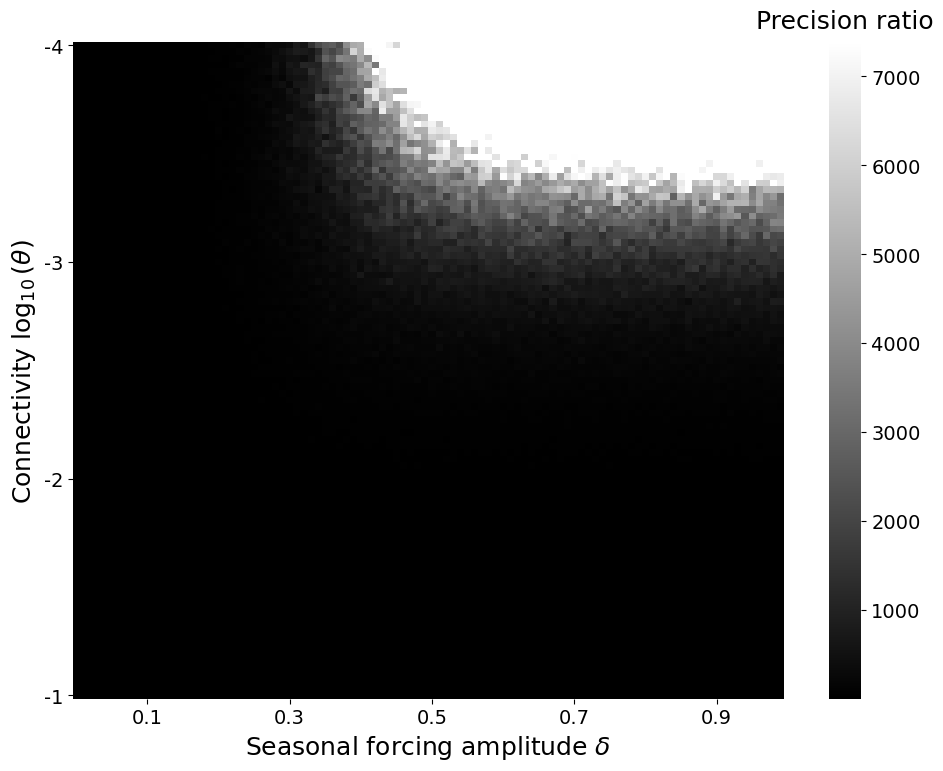

In [29]:
# ============================================================
# Figure 11 — Precision ratio heatmap (reverse-phase / in-phase) over
#             (theta, delta), with ICs drawn from the empirical distribution.
#             Values > 1 mean reverse-phase is more informative than in-phase.
# Output: pix/crlb_ratio.pdf
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed


def median_ratio(pp):
    # Precision(reverse-phase) / precision(in-phase); ratio > 1 when
    # reverse-phase pairs carry more Fisher info than in-phase pairs.
    sync = pp.query("phase2 == 0").precision.values
    unsync = pp.query("phase2 > 0").precision.values
    if len(sync) == 0 or len(unsync) == 0:
        return np.nan
    med_sync = np.median(sync)
    if med_sync <= 0:
        return np.nan
    return np.median(unsync) / med_sync


df = pd.read_csv("outputs/precision.csv")
df = df.rename(columns={'delta': 'amplitude'})

groups = list(df.groupby(['amplitude', 'theta']))
results = Parallel(n_jobs=-1)(delayed(median_ratio)(group) for _, group in groups)
index = pd.MultiIndex.from_tuples([name for name, _ in groups], names=['amplitude', 'theta'])
agg = pd.Series(results, index=index)
heat = agg.unstack(level='amplitude')
heat.index = np.log10(heat.index)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
amplitudes = heat.columns.values
thetas = heat.index.values
vals = heat.values[np.isfinite(heat.values)]
vmax = np.percentile(vals, 90)

hm = sns.heatmap(heat, cmap='grey', xticklabels=False, yticklabels=False,
                 vmin=1, vmax=vmax, ax=ax, cbar=True, cbar_kws={})

cbar = hm.collections[0].colorbar
cbar.ax.set_title('Precision ratio', fontsize=18, pad=10)

x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
ax.set_xticks(x_positions)
ax.set_xticklabels(x_desired)
y_desired = [-1, -2, -3, -4]
y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_desired)
ax.set_xlabel(r'Seasonal forcing amplitude $\delta$', fontsize=18)
ax.set_ylabel(r'Connectivity $\log_{10}(\theta)$', fontsize=18)

plt.tight_layout()
plt.savefig("pix/crlb_ratio.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/crlb_ratio.pdf", bbox_inches='tight')
plt.show()

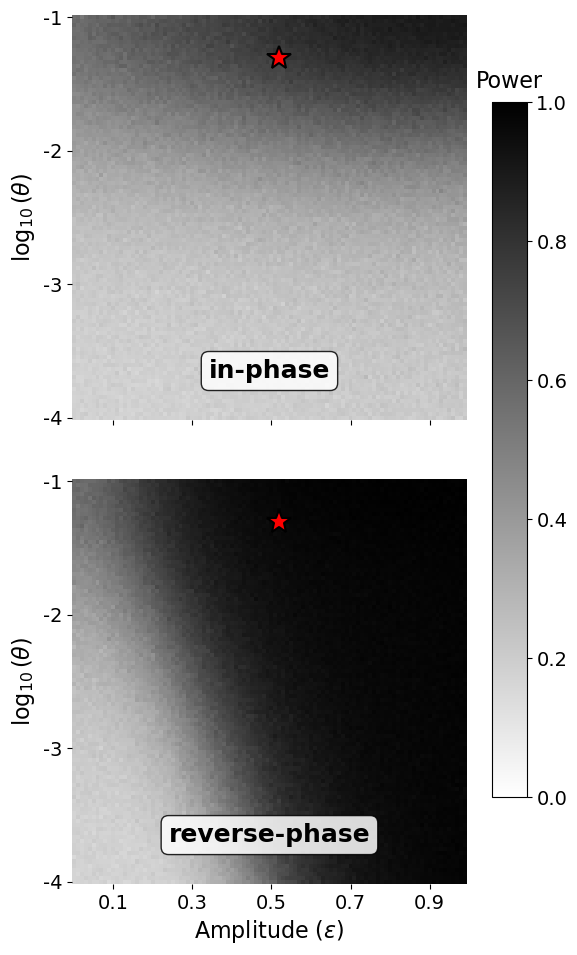

In [30]:
# ============================================================
# Figure 12 — Power heatmap (in-phase vs reverse-phase) with ICs
#             from the empirical distribution. Power is computed
#             under the 12-season aggregation used for the real-data
#             analysis (Fisher informations add). A red star marks
#             the flu operating point (theta = 0.05, delta = 0.517).
# Output: pix/power.pdf
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})

# Flu operating point (from paper parameter table)
THETA_FLU = 0.05    # 5% connectivity
DELTA_FLU = 0.517   # seasonal forcing amplitude for flu

df = pd.read_csv("outputs/precision.csv", index_col=None)
df = df.rename(columns={'delta': 'amplitude'})
df['phase2'] = df.phase2.replace({np.pi: 'reverse-phase', 0: 'in-phase'})
df['log_theta'] = np.log10(df.theta)

z_alpha = norm.isf(0.05) #1.645

# 12-season aggregation: I_theta_total = 12 * I_theta_per_season, so aggregate
# std = 1/sqrt(12 * precision). SNR = theta / std = theta * sqrt(12 * precision).
df['power'] = 1 - norm.cdf(z_alpha - df['theta'] * np.sqrt(12 * df['precision']))


def draw_heatmap(data, **kwargs):
    pivot = data.pivot(index='theta', columns='amplitude', values='power')
    thetas = pivot.index.values
    amplitudes = pivot.columns.values
    ax = plt.gca()
    sns.heatmap(pivot, ax=ax, cmap='gray_r', vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.invert_yaxis()
    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    y_desired_theta = [0.1, 0.01, 0.001, 0.0001]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired_theta]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['-1', '-2', '-3', '-4'])

    # Red star at the flu operating point (theta, delta).
    x_flu = np.argmin(np.abs(amplitudes - DELTA_FLU)) + 0.5
    y_flu = np.argmin(np.abs(thetas - THETA_FLU)) + 0.5
    ax.plot(x_flu, y_flu, marker='*', color='red', markersize=18,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10,
            linestyle='None')


df_agg = df.groupby(['theta', 'amplitude', 'phase2'])['power'].mean().reset_index()

# Side-by-side panels: in-phase on left, reverse-phase on right
g = sns.FacetGrid(df_agg, col='phase2',
                  col_order=['in-phase', 'reverse-phase'],
                  height=5, aspect=1.2)
g.map_dataframe(draw_heatmap)
g.set_axis_labels(r'Amplitude ($\epsilon$)', r'$\log_{10}(\theta)$')
g.set_titles(col_template='')  # suppress default top titles

# Panel label INSIDE each panel (top-center), with a semi-opaque white box
# so the text stays readable against the heatmap.
for ax, label in zip(g.axes.flat, ['in-phase', 'reverse-phase']):
    ax.text(0.5, 0.15, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=18, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='black', alpha=0.85))

sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(0, 1))
sm.set_array([])
# Colorbar: no side label; place "Power" as a title above the bar.
cbar = g.figure.colorbar(sm, ax=g.axes, location='right', shrink=0.8)
cbar.ax.set_title('Power', fontsize=16, pad=10)

plt.savefig("pix/power.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/power.pdf", bbox_inches='tight')
plt.show()

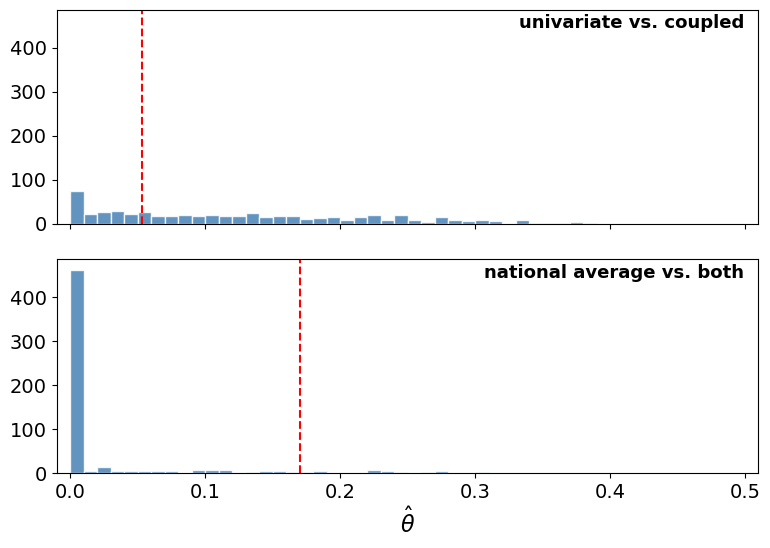

In [15]:
# ============================================================
# Distribution of inferred theta for the two SIR models where
# theta is a free parameter (coupled, both). The two trivial
# (theta == 0) cases are omitted for clarity.
# ============================================================
import glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
fold = True
# One row per (pair, model config): theta and crlb_theta are constant across seasons.
rows = []
for f in sorted(glob.glob('outputs/states/*.csv')):
    df = pd.read_csv(f)
    if 'alpha_limit' not in df.columns:
        continue
    df = df.drop_duplicates(subset=['state1', 'state2', 'alpha_limit', 'theta_limit'])
    rows.append(df)
all_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

# Vertical stack: top = coupled (no all-others), bottom = both (with all-others).
models = [
    ((0.0, 1.0), 'univariate vs. coupled'),
    ((1.0, 1.0), 'national average vs. both'),
]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, sharey=True)
for i, ((au, tu), name) in enumerate(models):
    ax = axes[i]
    sub = all_df[(all_df['alpha_limit'] == au) & (all_df['theta_limit'] == tu)]
    theta = sub['theta'].dropna().values
    if fold:
        theta = np.minimum(theta, 1-theta)
    sigma = np.sqrt(sub['crlb_theta'].dropna().values)
    n_pairs = len(theta)

    ax.hist(theta, bins=100, range=(0, 1),
            color='steelblue', edgecolor='white', alpha=0.85, density=False)
    thresh = 1.645 * np.median(sigma)
    ax.axvline(thresh, color='red', linestyle='--', linewidth=1.5)
    #               label=fr'reject $H_0$: $\hat\theta > 1.645\,\tilde\sigma_\theta = {thresh:.3f}$')
    n_reject = int((theta > thresh).sum())
    # ax.text(0.98, 0.88,
    #         fr'n = {n_pairs};   median $\hat\theta = {np.median(theta):.3f}$'
    #         + f'\nreject (median-\u03c3): {n_reject}/{n_pairs} ({100*n_reject/n_pairs:.1f}%)',
    #         ha='right', va='top', transform=ax.transAxes, fontsize=10)
    #ax.legend(loc='upper center', fontsize=10)
    ax.text(0.98, 0.98, name, ha='right', va='top',
            transform=ax.transAxes, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.01, 0.51 + int(not fold)/2)

axes[-1].set_xlabel(r'$\hat\theta$')

#fig.suptitle('Distribution of fitted coupling parameter', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('pix/theta_distribution_models.pdf', bbox_inches='tight')
fig.savefig('pix/theta_distribution_models.png', dpi=150, bbox_inches='tight')
plt.show()


In [57]:
# ============================================================
# Scatter of theta_hat vs sigma_theta per pair, with the Wald
# rejection region marked by a diagonal line. Two panels: coupled
# (top) and both (bottom). Unlike the histogram above (which has a
# single median-based rejection line), here every pair sits at its
# own point and the diagonal is the honest per-pair boundary.
#
# Uses all_df loaded by the theta-distribution cell above.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Z_ALPHA = norm.isf(0.05)   # ~1.645
FOLD = True

models = [((0.0, 1.0), 'coupled'), 
          ((1.0, 1.0), 'both')]

for (au, tu), name in models:
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    sub = all_df[(all_df['alpha_limit'] == au) & (all_df['theta_limit'] == tu)].copy()
    theta = sub['theta'].values
    if FOLD:
        theta = np.minimum(theta, 1 - theta)
    sigma = np.sqrt(sub['crlb_theta'].values)
    ok = np.isfinite(sigma) & (sigma > 0) & np.isfinite(theta)
    theta, sigma = theta[ok], sigma[ok]
    
    reject = theta > Z_ALPHA * sigma
    
    theta_max = 0.5 if FOLD else 1.0
    sigma_max = np.percentile(sigma, 99) * 1.05
    xmin=-0.005
    t = np.linspace(xmin, theta_max, 200)
    sig_line = t / Z_ALPHA
    ax.fill_between(t, sig_line, sigma_max, color='#D5E8F0', zorder=0)   # H0 not rejected
    ax.fill_between(t, 0,        sig_line,  color='#FDEBD0', zorder=0)   # H0 rejected
    ax.plot(t, sig_line, 'k--', linewidth=1.5, zorder=2)
    
    ax.scatter(theta[~reject], sigma[~reject],
               s=25, color='black', alpha=0.65, marker='o', zorder=3)
    ax.scatter(theta[ reject], sigma[ reject],
               s=80, color='red', alpha=0.9, marker='*', zorder=4)
    
    ax.text(0.2 * theta_max, 0.75 * sigma_max, r'$H_0:\theta = 0$',
            fontsize=16, color='#2171B5', ha='center', va='center', style='italic')
    ax.text(0.8 * theta_max, 0.10 * sigma_max, r'$H_1:\theta > 0$',
            fontsize=16, color='#D95F02', ha='center', va='center', style='italic')
    
    ax.set_xlim(xmin, theta_max)
    ax.set_ylim(0, sigma_max)
    ax.set_xlabel(r'$\hat{\theta}$', fontsize=20)
    ax.set_ylabel(r'$I^{-1/2}(\theta)$', fontsize=20)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    fname = f'pix/theta_vs_crlb_{name}.'
    plt.savefig(fname  + 'pdf', bbox_inches='tight')
    plt.savefig(fname + 'png', dpi=150, bbox_inches='tight')
    plt.close()
    print(name, "rejected fraction", np.mean(reject))

coupled rejected fraction 0.7966942148760331
both rejected fraction 0.17520661157024794
